# Prétraitement – Projet ML 2026
### Dataset : Recyclage de Déchets

**Pipeline :**
1. Import & Exploration  
2. Analyse des valeurs manquantes (MCAR / MAR / MNAR)  
3.  Imputation  
4. Traitement des Outliers  
5. Normalisation / Standardisation  
6. Encodage des variables catégoriques  
7. Dataset final

---

## 0. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import mean_squared_error

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("✅ Librairies chargées")

✅ Librairies chargées


---
## 1. Import du Dataset

In [2]:
df = pd.read_csv("dataset_ProjetML_2026.csv")
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")

Dimensions : 10500 lignes × 9 colonnes


In [3]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


In [4]:
df.dtypes

Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie            object
Source               object
Rapport_Collecte     object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB


---
## 2. Exploration

### 2.1 Statistiques descriptives

In [6]:
NUM_COLS = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite", "Prix_Revente"]
CAT_COLS = ["Categorie", "Source"]

df[NUM_COLS].describe().round(3)

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000,9960.000,9483.000,9465.000,9942.000,9964.000
mean,77.797,144.408,0.208,1.160,5.887,58.588
std,127.847,136.384,0.379,5.493,3.087,720.059
min,-99.000,-26.808,0.000,0.000,1.000,-50.000
25%,19.752,44.437,0.000,0.196,3.000,1.394
50%,39.193,88.084,0.000,0.553,5.000,4.135
75%,130.498,240.200,0.000,1.000,9.000,6.782
max,2334.219,554.107,0.999,55.000,10.000,9999.000


### 2.2 Distribution des variables catégoriques

In [7]:
for col in CAT_COLS:
    print(f"\n── {col} ──")
    print(df[col].value_counts(dropna=False))


── Categorie ──
Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
NaN           514
Name: count, dtype: int64

── Source ──
Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
NaN                    536
Name: count, dtype: int64


### 2.3 Valeurs manquantes

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Nb NaN": missing, "% NaN": missing_pct})
missing_df[missing_df["Nb NaN"] > 0].sort_values("% NaN", ascending=False)

,Nb NaN,% NaN
Opacite,1035,9.86
Poids,1029,9.80
Conductivite,1017,9.69
Rigidite,558,5.31
Volume,540,5.14
Prix_Revente,536,5.10
Source,536,5.10
Categorie,514,4.90


### 2.4 Histogrammes des variables numériques

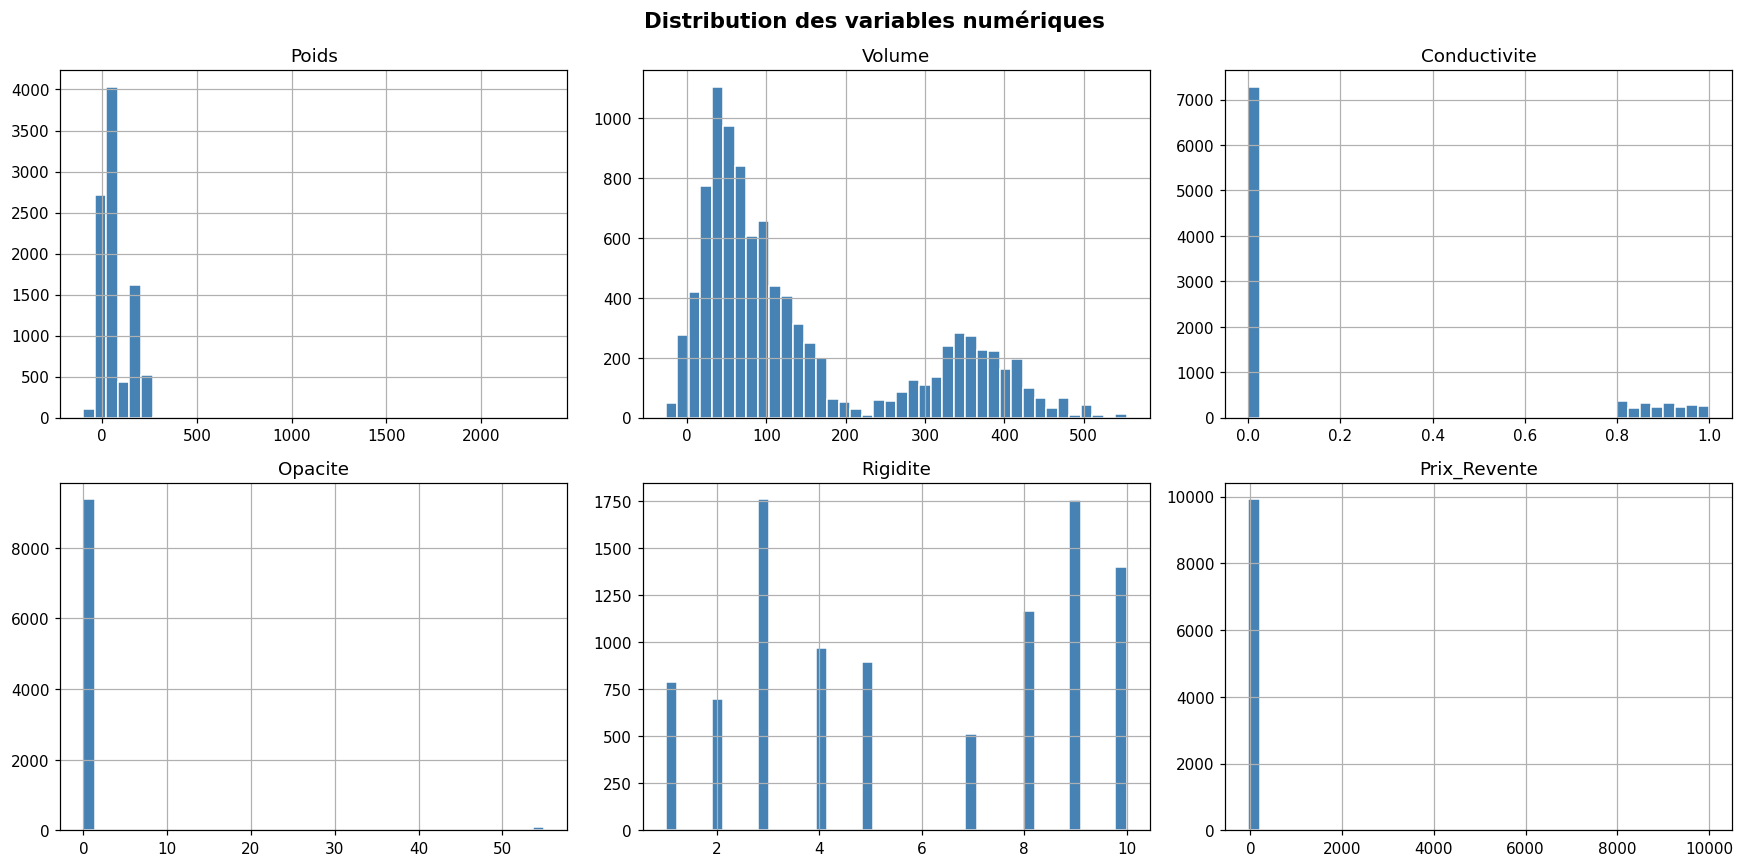

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Distribution des variables numériques", fontsize=14, fontweight="bold")

for i, col in enumerate(NUM_COLS):
    ax = axes[i // 3, i % 3]
    df[col].dropna().hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

### 2.5 Carte des valeurs manquantes

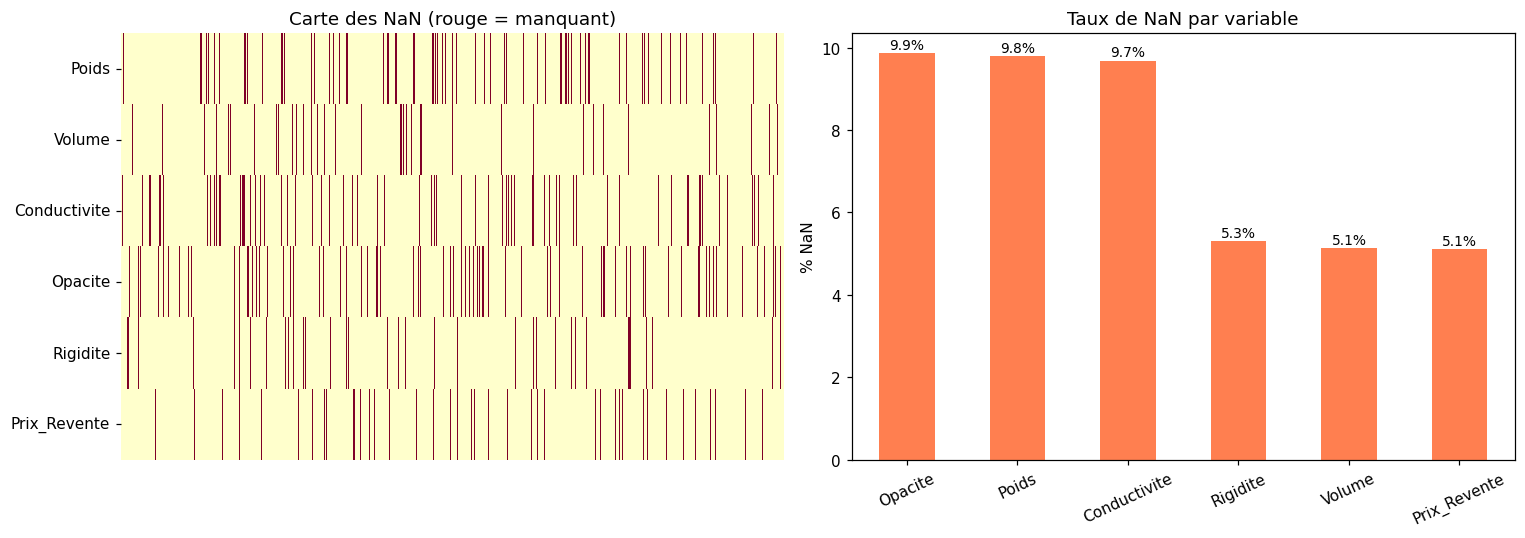

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap NaN
sns.heatmap(df[NUM_COLS].isnull().astype(int).T,
            ax=axes[0], cbar=False, cmap="YlOrRd",
            yticklabels=NUM_COLS, xticklabels=False)
axes[0].set_title("Carte des NaN (rouge = manquant)")

# Bar chart % NaN
miss_pct = (df[NUM_COLS].isnull().mean() * 100).sort_values(ascending=False)
miss_pct.plot(kind="bar", ax=axes[1], color="coral", rot=25)
axes[1].set_ylabel("% NaN")
axes[1].set_title("Taux de NaN par variable")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.1),
                     ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### 2.6 Distribution des variables catégoriques

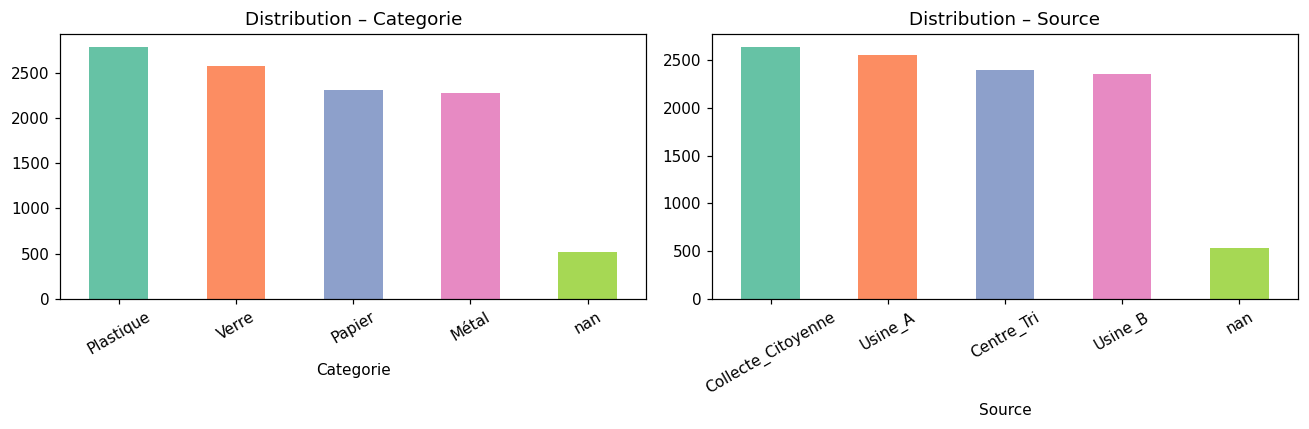

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(CAT_COLS):
    df[col].value_counts(dropna=False).plot(
        kind="bar", ax=axes[i],
        color=sns.color_palette("Set2", 5), rot=30)
    axes[i].set_title(f"Distribution – {col}")
plt.tight_layout()
plt.show()

---
##  3. Analyse des Valeurs Manquantes (MCAR / MAR / MNAR)



### 3.1 Test MCAR – Corrélations entre indicateurs de NaN

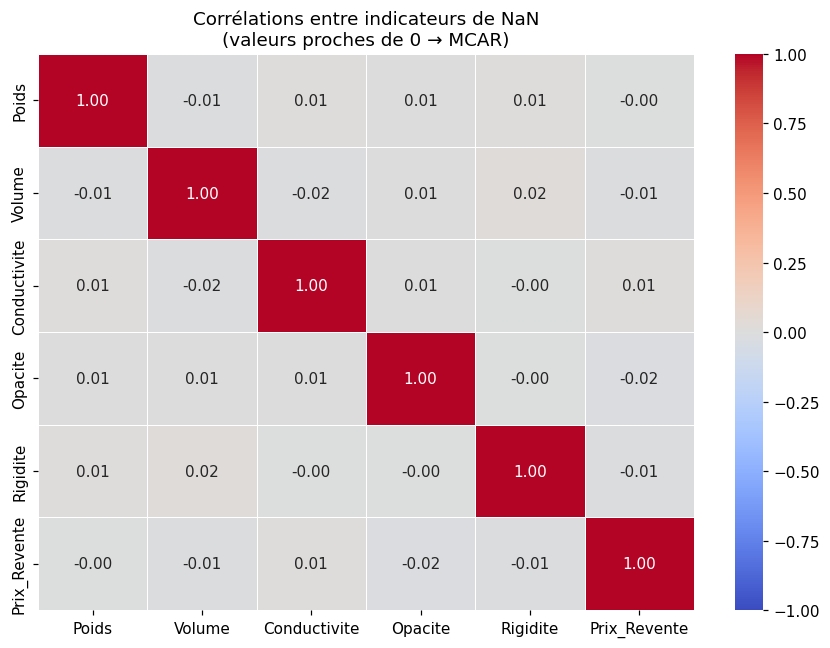

→ Toutes les corrélations < 0.05 : les NaN sont indépendants entre variables ⟹ MCAR


In [12]:
M = df[NUM_COLS].isnull().astype(int)
corr_nan = M.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_nan, annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Corrélations entre indicateurs de NaN\n(valeurs proches de 0 → MCAR)")
plt.tight_layout()
plt.show()

print("→ Toutes les corrélations < 0.05 : les NaN sont indépendants entre variables ⟹ MCAR")

### 3.2 Test MAR – Dépendance à la Catégorie

In [13]:
print("Taux de NaN par Catégorie (std faible → MCAR) :\n")
for col in NUM_COLS:
    tmp = df.copy()
    tmp["_nan"] = tmp[col].isnull().astype(int)
    variance = tmp.groupby("Categorie", dropna=False)["_nan"].mean().std()
    print(f"  {col:20s}  std = {variance:.4f}")

print("\n→ Faible variance ⟹ NaN indépendants de la Catégorie ⟹ MCAR confirmé")

Taux de NaN par Catégorie (std faible → MCAR) :

  Poids                 std = 0.0112
  Volume                std = 0.0021
  Conductivite          std = 0.0099
  Opacite               std = 0.0151
  Rigidite              std = 0.0061
  Prix_Revente          std = 0.0061

→ Faible variance ⟹ NaN indépendants de la Catégorie ⟹ MCAR confirmé


### 3.3 Analyse MNAR (raisonnement métier)

In [14]:
# Conductivite : 75% des valeurs sont 0.0
print("Conductivite – valeurs = 0 :", (df["Conductivite"] == 0).sum(),
      "/", df["Conductivite"].notna().sum())
print("→ NaN = non mesuré car non applicable (Papier, Verre) ⟹ MNAR\n")

# Prix_Revente : outlier extrême
print("Prix_Revente = 9999 :", (df["Prix_Revente"] == 9999).sum())
print("→ Lots non évalués car peu valorisables ⟹ MNAR partiel")

Conductivite – valeurs = 0 : 7283 / 9483
→ NaN = non mesuré car non applicable (Papier, Verre) ⟹ MNAR

Prix_Revente = 9999 : 52
→ Lots non évalués car peu valorisables ⟹ MNAR partiel


### 3.4 Classification finale



---
##  4. Imputation des Valeurs Manquantes



### 4.1 Comparaison des 3 stratégies

In [15]:
np.random.seed(42)
df_complete = df[NUM_COLS].dropna().copy()
n_mask = int(0.10 * df_complete.shape[0])
eval_results = {}

for col in NUM_COLS:
    idx_mask = np.random.choice(df_complete.index, size=n_mask, replace=False)
    true_vals = df_complete.loc[idx_mask, col].values
    df_test = df_complete.copy()
    df_test.loc[idx_mask, col] = np.nan

    # Médiane
    d_med = pd.DataFrame(
        SimpleImputer(strategy="median").fit_transform(df_test),
        index=df_test.index, columns=NUM_COLS)
    rmse_med = np.sqrt(mean_squared_error(true_vals, d_med.loc[idx_mask, col].values))

    # KNN
    d_knn = pd.DataFrame(
        KNNImputer(n_neighbors=5).fit_transform(df_test),
        index=df_test.index, columns=NUM_COLS)
    rmse_knn = np.sqrt(mean_squared_error(true_vals, d_knn.loc[idx_mask, col].values))

    # Iterative
    d_iter = pd.DataFrame(
        IterativeImputer(random_state=42, max_iter=10).fit_transform(df_test),
        index=df_test.index, columns=NUM_COLS)
    rmse_iter = np.sqrt(mean_squared_error(true_vals, d_iter.loc[idx_mask, col].values))

    eval_results[col] = {
        "Médiane": round(rmse_med, 4),
        "KNN (k=5)": round(rmse_knn, 4),
        "IterativeImputer": round(rmse_iter, 4),
    }

results_df = pd.DataFrame(eval_results).T
results_df["✅ Meilleure"] = results_df[["Médiane","KNN (k=5)","IterativeImputer"]].idxmin(axis=1)
results_df

,Médiane,KNN (k=5),IterativeImputer,✅ Meilleure
Poids,201.2327,177.3880,172.5107,IterativeImputer
Volume,157.3510,21.0700,58.8315,KNN (k=5)
Conductivite,0.4317,0.0286,0.2310,KNN (k=5)
Opacite,6.0187,2.2267,5.9854,KNN (k=5)
Rigidite,3.2242,0.2629,1.2506,KNN (k=5)
Prix_Revente,955.1710,1.2563,951.7867,KNN (k=5)


### 4.2 Visualisation comparaison RMSE

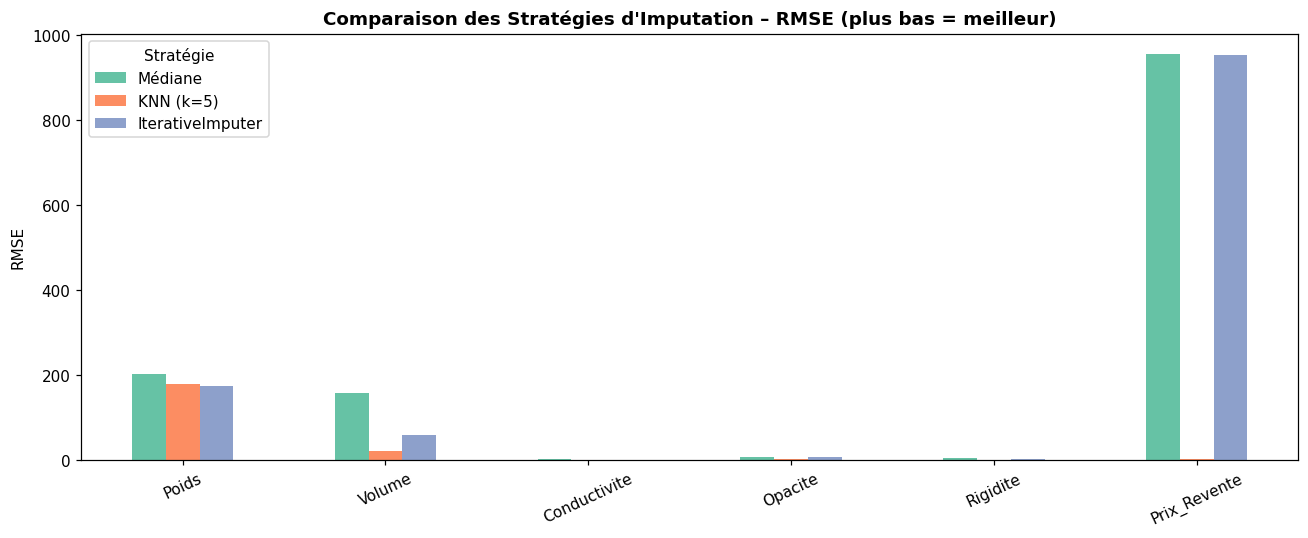

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
results_df[["Médiane", "KNN (k=5)", "IterativeImputer"]].plot(
    kind="bar", ax=ax,
    color=sns.color_palette("Set2", 3), rot=25)
ax.set_title("Comparaison des Stratégies d'Imputation – RMSE (plus bas = meilleur)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("RMSE")
ax.legend(title="Stratégie")
plt.tight_layout()
plt.show()

### 4.3 Application de l'imputation sur le dataset

In [17]:
# Variables numériques → IterativeImputer
df["Rapport_Collecte_backup"] = df["Rapport_Collecte"]  # sauvegarde texte

imp = IterativeImputer(random_state=42, max_iter=10)
df[NUM_COLS] = imp.fit_transform(df[NUM_COLS])
print("✅ Variables numériques imputées (IterativeImputer)")

✅ Variables numériques imputées (IterativeImputer)


In [18]:
# Variables catégoriques → mode
for col in CAT_COLS:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  {col:15s} → mode = '{mode_val}'")

print(f"\n✅ NaN restants : {df[NUM_COLS + CAT_COLS].isnull().sum().sum()}")

  Categorie       → mode = 'Plastique'
  Source          → mode = 'Collecte_Citoyenne'

✅ NaN restants : 0


---
##  5. Traitement des Outliers

**Détection :** IQR + Z-score  
**Traitement :** Winsorization (capping P1 – P99)

### 5.1 Détection – Méthode IQR

In [19]:
print(f"{'Variable':20s} {'Outliers IQR':>15} {'Outliers Z>3':>14}")
print("-" * 52)
for col in NUM_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_iqr = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    n_z   = (np.abs(stats.zscore(df[col])) > 3).sum()
    print(f"  {col:20s} {n_iqr:>12}   {n_z:>12}")

Variable                Outliers IQR   Outliers Z>3
----------------------------------------------------
  Poids                          61             49
  Volume                         13             13
  Conductivite                 2313              0
  Opacite                        97             97
  Rigidite                        0              0
  Prix_Revente                  573             52


### 5.2 Boxplots avant traitement

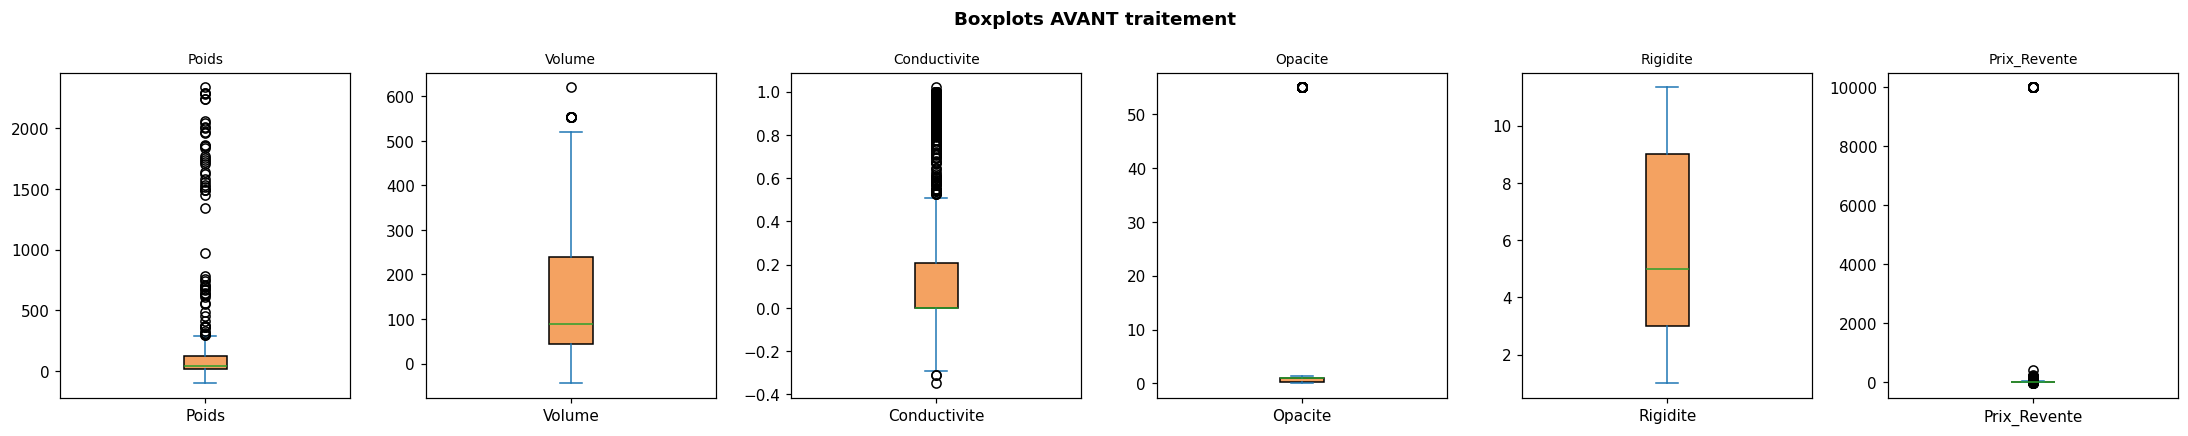

In [20]:
fig, axes = plt.subplots(1, len(NUM_COLS), figsize=(20, 4))
fig.suptitle("Boxplots AVANT traitement", fontsize=12, fontweight="bold")
for i, col in enumerate(NUM_COLS):
    df[col].plot(kind="box", ax=axes[i], patch_artist=True,
                 boxprops=dict(facecolor="#f4a261"))
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

### 5.3 Correction des valeurs négatives impossibles

In [21]:
for col in ["Poids", "Volume"]:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        df[col] = df[col].clip(lower=0)
        print(f"  {col}: {n_neg} valeurs négatives → corrigées à 0")

  Poids: 145 valeurs négatives → corrigées à 0
  Volume: 278 valeurs négatives → corrigées à 0


### 5.4 Capping (Winsorization P1 – P99)

In [22]:
for col in NUM_COLS:
    low  = df[col].quantile(0.01)
    high = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=low, upper=high)
    print(f"  {col:20s} → [{low:.3f}, {high:.3f}]")

print("\n✅ Capping appliqué sur toutes les variables numériques")

  Poids                → [0.000, 251.704]
  Volume               → [0.000, 473.136]
  Conductivite         → [-0.125, 0.988]
  Opacite              → [0.009, 1.338]
  Rigidite             → [1.000, 10.000]
  Prix_Revente         → [0.365, 134.407]

✅ Capping appliqué sur toutes les variables numériques


### 5.5 Boxplots après traitement

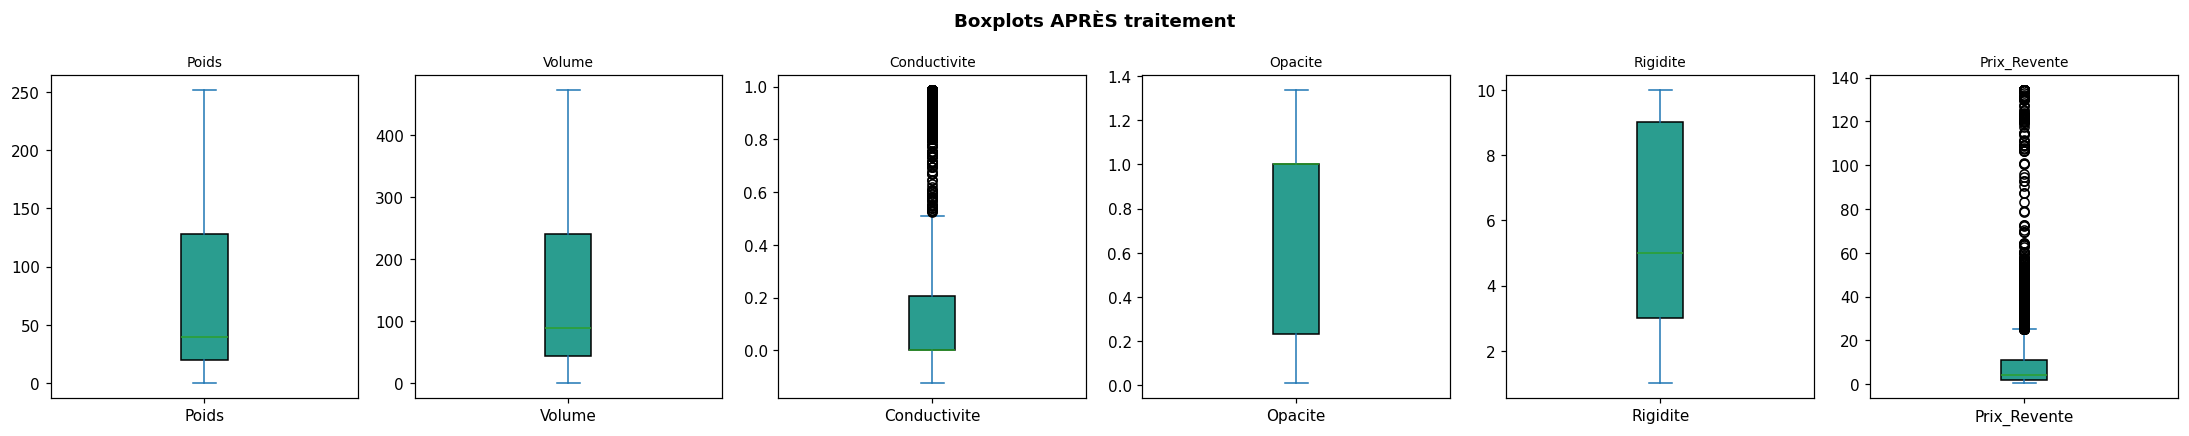

In [23]:
fig, axes = plt.subplots(1, len(NUM_COLS), figsize=(20, 4))
fig.suptitle("Boxplots APRÈS traitement", fontsize=12, fontweight="bold")
for i, col in enumerate(NUM_COLS):
    df[col].plot(kind="box", ax=axes[i], patch_artist=True,
                 boxprops=dict(facecolor="#2a9d8f"))
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

---
##  6. Normalisation / Standardisation



### 6.1 Distribution avant scaling

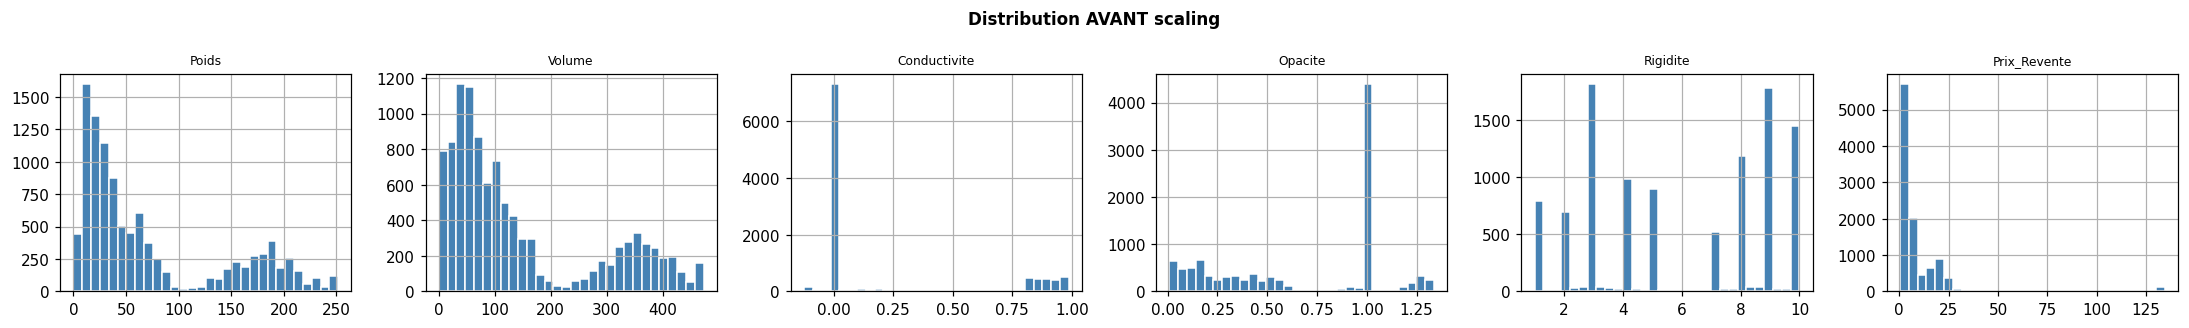

In [25]:
fig, axes = plt.subplots(1, len(NUM_COLS), figsize=(20, 3))
fig.suptitle("Distribution AVANT scaling", fontsize=11, fontweight="bold")
for i, col in enumerate(NUM_COLS):
    df[col].hist(bins=30, ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=8)
plt.tight_layout()
plt.show()

### 6.2 Application du RobustScaler

In [26]:
scaler = RobustScaler()
df[NUM_COLS] = scaler.fit_transform(df[NUM_COLS])
print("✅ RobustScaler appliqué")
df[NUM_COLS].describe().round(3)

✅ RobustScaler appliqué


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,10500.000,10500.000,10500.000,10500.000,10500.000,10500.000
mean,0.300,0.281,0.996,-0.437,0.148,0.547
std,0.639,0.688,1.784,0.543,0.512,1.880
min,-0.367,-0.458,-0.604,-1.295,-0.667,-0.424
25%,-0.185,-0.228,0.000,-1.000,-0.333,-0.281
50%,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.815,0.772,1.000,0.000,0.667,0.719
max,1.950,1.964,4.776,0.441,0.833,13.803


### 6.3 Distribution après scaling

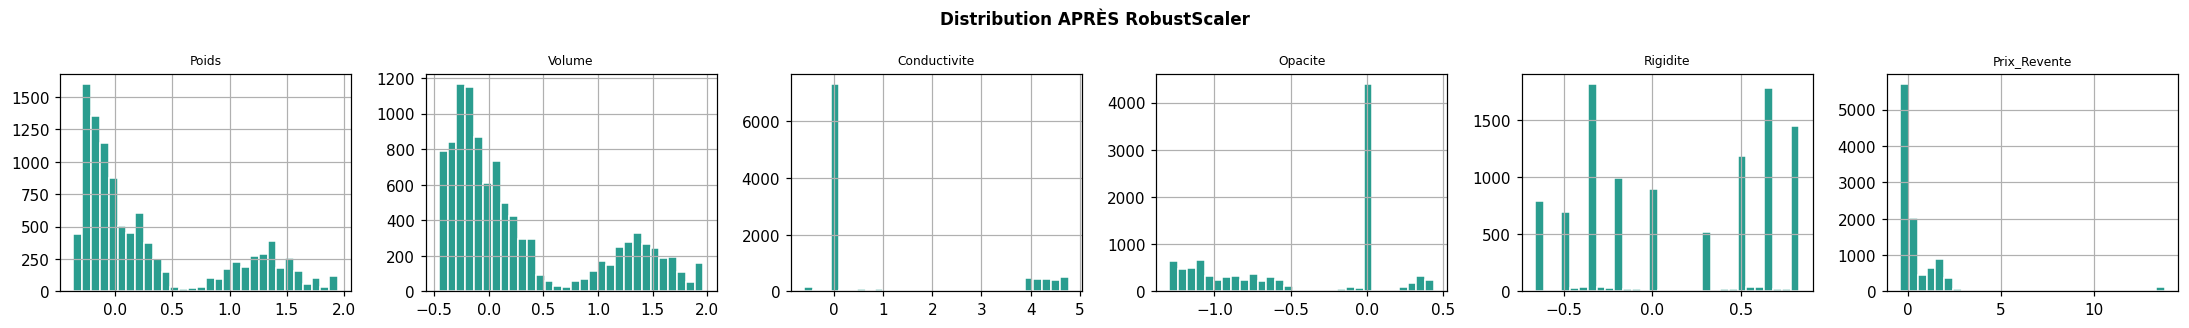

In [27]:
fig, axes = plt.subplots(1, len(NUM_COLS), figsize=(20, 3))
fig.suptitle("Distribution APRÈS RobustScaler", fontsize=11, fontweight="bold")
for i, col in enumerate(NUM_COLS):
    df[col].hist(bins=30, ax=axes[i], color="#2a9d8f", edgecolor="white")
    axes[i].set_title(col, fontsize=8)
plt.tight_layout()
plt.show()

---
##  7. Encodage des Variables Catégoriques

**Méthode choisie : LabelEncoder**  
→ Adapté aux modèles arborescents (Random Forest, XGBoost)  
→ Compact : pas d'ajout de colonnes

### 7.1 Avant encodage

In [28]:
print("Valeurs uniques avant encodage :")
for col in CAT_COLS:
    print(f"  {col}: {df[col].unique().tolist()}")

Valeurs uniques avant encodage :
  Categorie: ['Papier', 'Plastique', 'Verre', 'Métal']
  Source: ['Collecte_Citoyenne', 'Usine_A', 'Usine_B', 'Centre_Tri']


### 7.2 Application du LabelEncoder

In [29]:
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  {col}: {mapping}")

  Categorie: {'Métal': np.int64(0), 'Papier': np.int64(1), 'Plastique': np.int64(2), 'Verre': np.int64(3)}
  Source: {'Centre_Tri': np.int64(0), 'Collecte_Citoyenne': np.int64(1), 'Usine_A': np.int64(2), 'Usine_B': np.int64(3)}


### 7.3 Vérification après encodage

In [30]:
print("Valeurs uniques après encodage :")
for col in CAT_COLS:
    print(f"  {col}: {sorted(df[col].unique().tolist())}")

Valeurs uniques après encodage :
  Categorie: [0, 1, 2, 3]
  Source: [0, 1, 2, 3]


---
##  8. Dataset Final

### 8.1 Suppression des colonnes inutiles

In [31]:
# Supprimer les colonnes texte brutes (non exploitables en ML)
df.drop(columns=["Rapport_Collecte", "Rapport_Collecte_backup"], inplace=True, errors="ignore")
print("Colonnes finales :", df.columns.tolist())

Colonnes finales : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Categorie', 'Source']


### 8.2 Aperçu du dataset final

In [32]:
print(f"Shape final : {df.shape}")
df.head(10)

Shape final : (10500, 8)


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source
0,-0.213295,-0.094685,0.000000,0.000000,-0.666667,-0.373730,1,1
1,0.068157,-0.126620,0.000000,0.330762,-0.333333,0.039389,2,2
2,1.213444,1.167105,0.000000,-0.025516,0.666667,-0.015373,3,3
3,-0.286822,-0.347923,0.000000,0.385828,-0.666667,-0.415481,1,0
4,-0.089717,-0.153450,0.000000,0.000000,-0.264757,-0.385663,1,3
5,-0.063715,-0.232797,0.000000,-0.846500,-0.166667,-0.112628,2,3
6,1.361606,1.590759,0.000000,-1.290444,0.500000,0.135449,3,1
7,0.849752,0.833997,0.000000,-1.292309,0.666667,-0.041565,3,1
8,-0.213263,-0.091029,0.000000,0.000000,-0.666667,-0.373711,1,2
9,0.186019,0.162081,4.611054,0.000000,0.333333,1.450573,0,0


### 8.3 Vérification – aucun NaN restant

In [33]:
print("NaN restants :", df.isnull().sum().sum())
df.isnull().sum()

NaN restants : 0


Poids           0
Volume          0
Conductivite    0
Opacite         0
Rigidite        0
Prix_Revente    0
Categorie       0
Source          0
dtype: int64

### 8.4 Matrice de corrélation

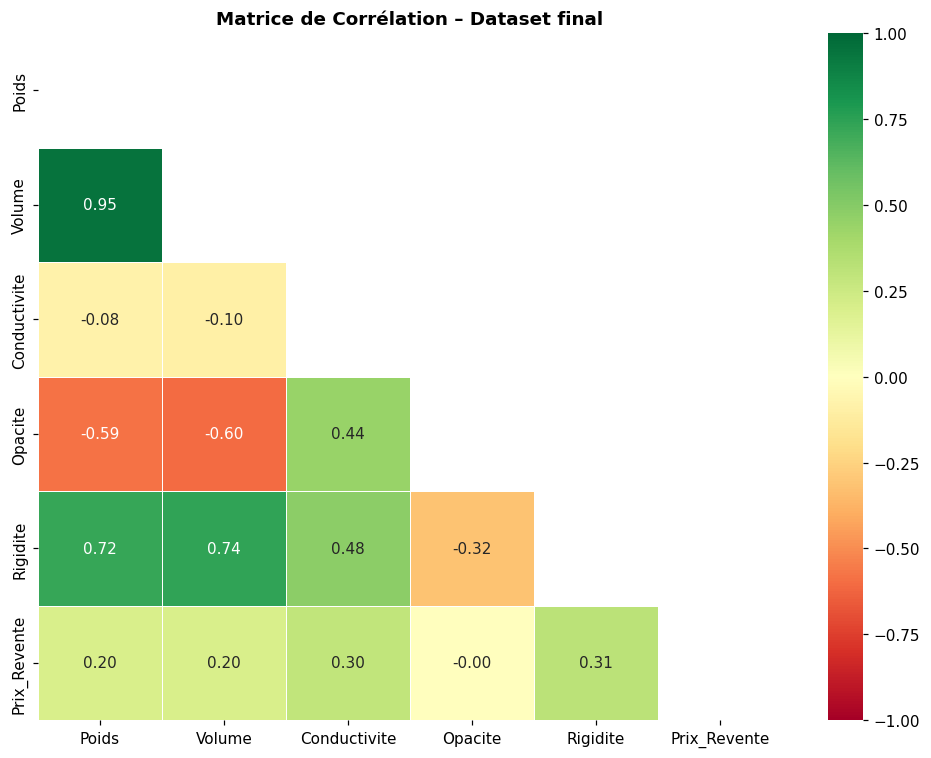

In [34]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[NUM_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1, center=0)
ax.set_title("Matrice de Corrélation – Dataset final",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 8.5 Sauvegarde

In [35]:
df.to_csv("dataset_final.csv", index=False)
print(f"✅ Dataset sauvegardé : dataset_final.csv")
print(f"   {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"   Colonnes : {df.columns.tolist()}")

✅ Dataset sauvegardé : dataset_final.csv
   10500 lignes × 8 colonnes
   Colonnes : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Categorie', 'Source']
